![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)

In diesem Notebook findest du eine beispielhafte Anwendung von Zeitreihen zur Analyse und Identifizierung von Kennzahlen. Es ist ein optionales Beispiel.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Laden des Datensatzes aus der Excel-Datei
df = pd.read_excel("kpi_datensatz.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Monat                           36 non-null     datetime64[ns]
 1   Umsatz                          36 non-null     float64       
 2   Herstellungskosten              36 non-null     float64       
 3   Betriebskosten                  36 non-null     float64       
 4   Lagerdauer_Tage                 36 non-null     int64         
 5   Forderungslaufzeit_Tage         36 non-null     int64         
 6   Verbindlichkeitenlaufzeit_Tage  36 non-null     int64         
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 2.1 KB


### Erklärung des Datensatzes für Finanz-KPIs

Dieser Datensatz enthält Finanzdaten eines fiktiven Unternehmens über einen Zeitraum von 3 Jahren. Die Daten ermöglichen die Berechnung wichtiger betriebswirtschaftlicher Kennzahlen KPIs = [Key Performance Indicators](https://wirtschaftslexikon.gabler.de/definition/key-performance-indicator-kpi-52670).

#### Spaltenbeschreibung:

- **Monat**: Der jeweilige Monat der Datenerfassung.
- **Umsatz**: Der Gesamtumsatz des Unternehmens in der jeweiligen Periode (in EUR).
- **Herstellungskosten**: Die Kosten der verkauften Waren (COGS - Cost of Goods Sold).
- **Betriebskosten**: Sonstige betriebliche Aufwendungen, z. B. Mieten, Löhne und sonstige Fixkosten.
- **Lagerdauer (Tage)**: Anzahl der Tage, die Waren durchschnittlich auf Lager liegen (Days Inventory Outstanding - DIO).
- **Forderungslaufzeit (Tage)**: Durchschnittliche Anzahl der Tage bis zur Zahlungseingang von Kunden (Days Sales Outstanding - DSO).
- **Verbindlichkeitenlaufzeit (Tage)**: Durchschnittliche Anzahl der Tage, die das Unternehmen zur Begleichung von Lieferantenverbindlichkeiten benötigt (Days Payable Outstanding - DPO).


#### KPIs:

- **Umsatzwachstum (%)**: Gibt an, wie stark der Umsatz im Vergleich zum Vormonat gewachsen ist:
 $$((UmsatzAktuell - UmsatzVorher) / UmsatzVorher) * 100$$
- **EBIT** (Earnings Before Interest and Taxes): Das Betriebsergebnis vor Zinsen und Steuern:
 $$Umsatz - Herstellungskosten - Betriebskosten$$
- **Bruttogewinnmarge (%)**: Verhältnis von Bruttogewinn zu Umsatz, zeigt die Rentabilität des Unternehmens:
  $$((Umsatz - Herstellungskosten) / Umsatz) * 100$$
- **Cash Conversion Cycle (Tage)**: Zeigt, wie lange es dauert, bis investiertes Kapital durch Verkäufe wieder zu Geld wird:
  $$Lagerdauer + Forderungslaufzeit - Verbindlichkeitenlaufzeit$$

Diese KPIs helfen dabei, die finanzielle Gesundheit eines Unternehmens zu analysieren und Verbesserungspotenziale in den Bereichen Umsatzwachstum, Rentabilität und Liquiditätsmanagement zu identifizieren.



In [4]:
# Umsatzwachstum (%)
df["Umsatzwachstum_%"] = df["Umsatz"].pct_change() * 100
#Die Funktion `.pct_change()` in Pandas berechnet die prozentuale Veränderung
# zwischen aufeinanderfolgenden Werten in einer Spalte oder einer Reihe von Werten.

# EBIT (Earnings Before Interest and Taxes)
df["EBIT"] = df["Umsatz"] - df["Herstellungskosten"] - df["Betriebskosten"]

# Bruttogewinnmarge (%)
df["Bruttogewinnmarge_%"] = ((df["Umsatz"] - df["Herstellungskosten"]) / df["Umsatz"]) * 100


# Cash Conversion Cycle (CCC)
df["Cash_Conversion_Cycle_Tage"] = (
    df["Lagerdauer_Tage"] + df["Forderungslaufzeit_Tage"] - df["Verbindlichkeitenlaufzeit_Tage"]
)

In [5]:
display(df.head())

,Monat,Umsatz,Herstellungskosten,Betriebskosten,Lagerdauer_Tage,Forderungslaufzeit_Tage,Verbindlichkeitenlaufzeit_Tage,Umsatzwachstum_%,EBIT,Bruttogewinnmarge_%,Cash_Conversion_Cycle_Tage
0,2021-01-31,82483.57,47937.07,19963.47,69,48,53,NaN,14583.03,41.882886,64
1,2021-02-28,87573.60,52719.90,15953.38,50,59,60,6.170962,18900.32,39.799323,49
2,2021-03-31,97590.23,59009.98,19664.73,67,31,37,11.437956,18915.52,39.532902,61
3,2021-04-30,104314.33,59301.18,19877.75,64,50,53,6.890136,25135.40,43.151454,61
4,2021-05-31,93633.55,60577.02,25944.09,78,41,54,-10.239034,7112.44,35.304151,65


In [6]:
# Berechneten Datensatz speichern
df.to_excel("kpi_bericht.xlsx", index=False)


Die KPIs lassen sich auf verschiedene Weise sinnvoll visualisieren, um Trends und Muster leicht zu erkennen. Hier sind einige der besten Methoden:

---

### 📊 **1. Umsatzentwicklung & Umsatzwachstum (%)**
**Visualisierung:**  
- **Liniendiagramm** für **Umsatz** über die Zeit
- **Balkendiagramm oder zweites Liniendiagramm** für das **Umsatzwachstum (%)**

📌 **Warum?**  
- Zeigt saisonale Schwankungen oder langfristige Trends im Umsatz.
- Umsatzwachstum in Prozent hilft dabei, starke oder schwache Perioden zu erkennen.

**📌 Umsetzung mit Matplotlib & Seaborn**

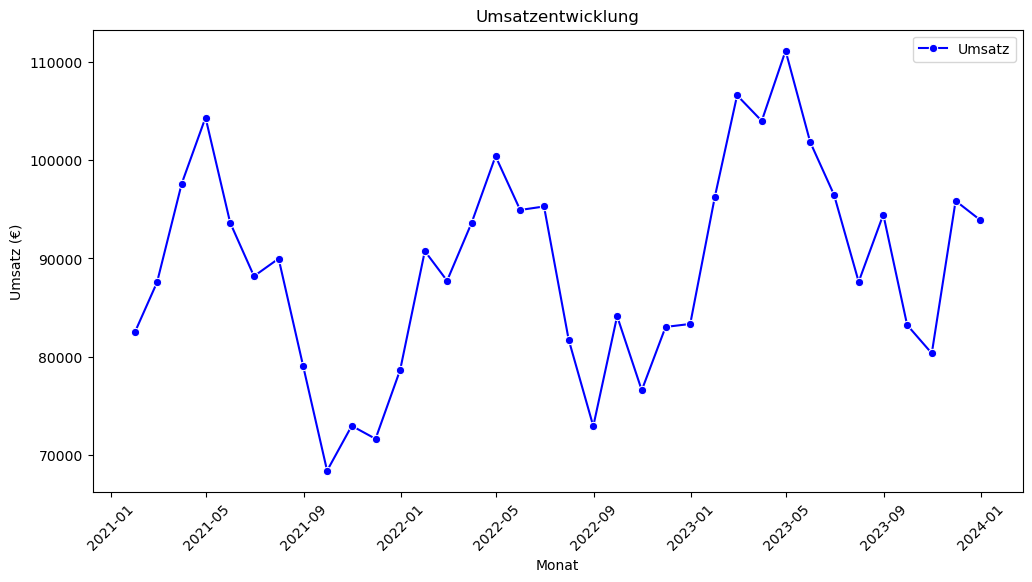

In [8]:
# Umsatz als Liniendiagramm
plt.figure(figsize=(12, 6))
sns.lineplot(x=df["Monat"], y=df["Umsatz"], marker="o", color="b", label="Umsatz")
plt.ylabel("Umsatz (€)")
plt.xlabel("Monat")
plt.title("Umsatzentwicklung")
plt.xticks(rotation=45)
plt.legend()
plt.show()


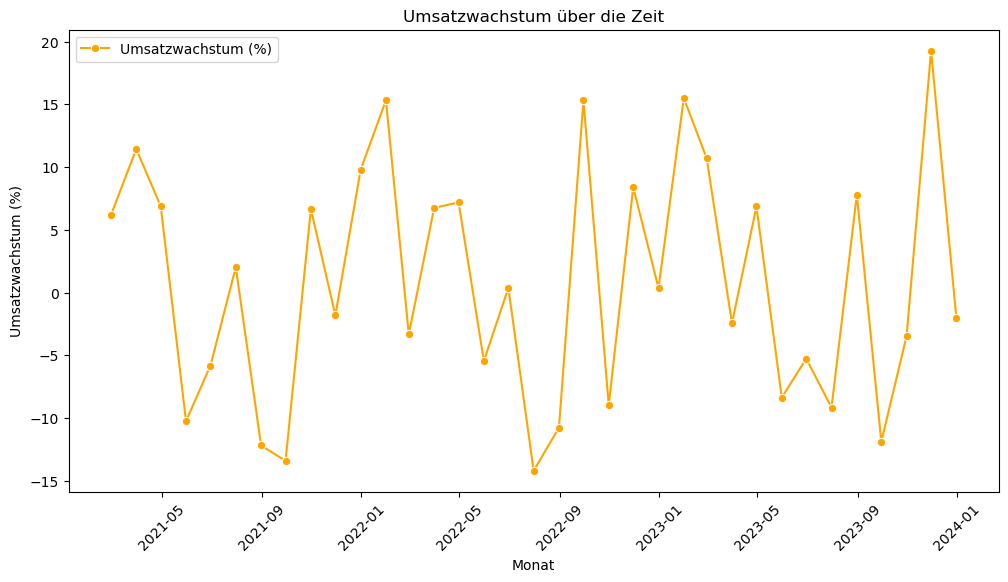

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df["Monat"], y=df["Umsatzwachstum_%"], marker="o", color="orange", label="Umsatzwachstum (%)")
plt.ylabel("Umsatzwachstum (%)")
plt.xlabel("Monat")
plt.title("Umsatzwachstum über die Zeit")
plt.xticks(rotation=45)
plt.legend()
plt.show()

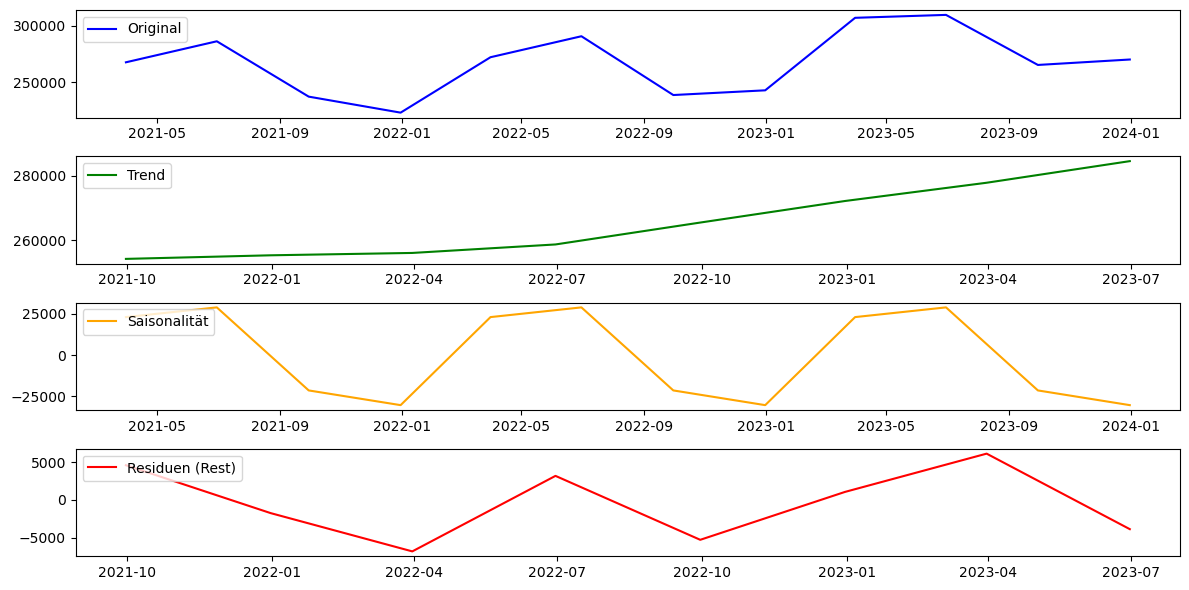

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

df.set_index("Monat", inplace=True)

# Quartalsweise Aggregation (optional, falls monatlich zu unruhig ist)
df_quartal = df.resample("QE").sum()

# Seasonal Decomposition mit additive oder multiplicative Methode
decomposition = seasonal_decompose(df_quartal["Umsatz"], model="additive", period=4)  # 4 Quartale pro Jahr

# Ergebnisse visualisieren
plt.figure(figsize=(12, 6))

plt.subplot(411)
plt.plot(df_quartal.index, df_quartal["Umsatz"], label="Original", color="blue")
plt.legend(loc="upper left")

plt.subplot(412)
plt.plot(decomposition.trend, label="Trend", color="green")
plt.legend(loc="upper left")

plt.subplot(413)
plt.plot(decomposition.seasonal, label="Saisonalität", color="orange")
plt.legend(loc="upper left")

plt.subplot(414)
plt.plot(decomposition.resid, label="Residuen (Rest)", color="red")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()


### 🚀 **Ergebnisanalyse**
✅ **Saisonalität erkennen** → Gibt es wiederkehrende Muster pro Quartal?  
✅ **Langfristige Trends identifizieren** → Steigt oder fällt der Umsatz dauerhaft?  
✅ **Unregelmäßige Schwankungen (Residuen) isolieren** → Welche Effekte sind nicht erklärbar?

Falls du eine **monatliche Analyse statt quartalsweise** möchtest, ändere `df_quartal = df.resample("Q").sum()` zu `df.resample("M").sum()` und passe `period=12` an.

---

### 💰 **2. Bruttogewinnmarge (%)**
**Visualisierung:**  
- **Liniendiagramm** für die **Bruttogewinnmarge (%)**  

📌 **Warum?**  
- Zeigt, ob die Rentabilität konstant ist oder variiert.

**📌 Umsetzung**

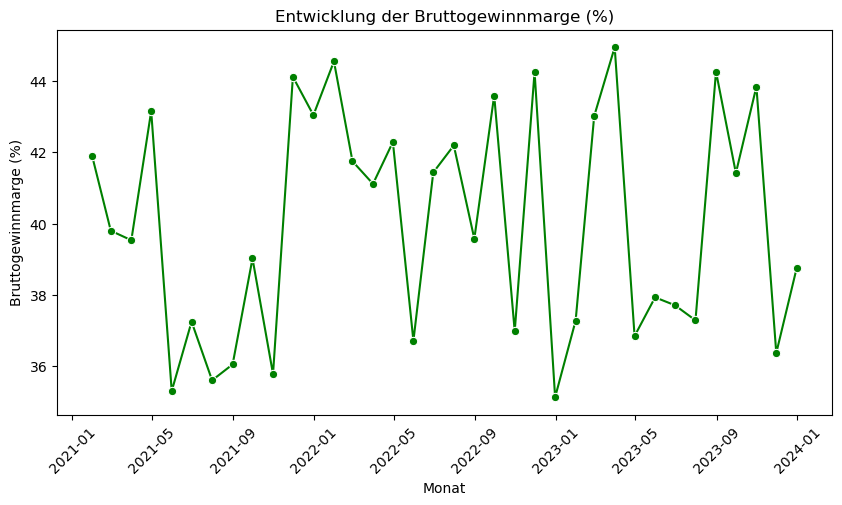

In [13]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=df.index, y=df["Bruttogewinnmarge_%"], marker="o", color="g")
plt.title("Entwicklung der Bruttogewinnmarge (%)")
plt.ylabel("Bruttogewinnmarge (%)")
plt.xticks(rotation=45)
plt.show()

---

### 📈 **3. EBIT (Earnings Before Interest and Taxes)**
**Visualisierung:**  
- **Balkendiagramm** für EBIT pro Monat  
- EBIT als **gestapeltes Balkendiagramm** mit Umsatz & Kosten, um die Verteilung zu sehen.

📌 **Warum?**  
- EBIT zeigt, ob das operative Geschäft profitabel ist.
- Ein gestapeltes Diagramm hilft zu verstehen, wie Kosten den Gewinn beeinflussen.

**📌 Umsetzung**

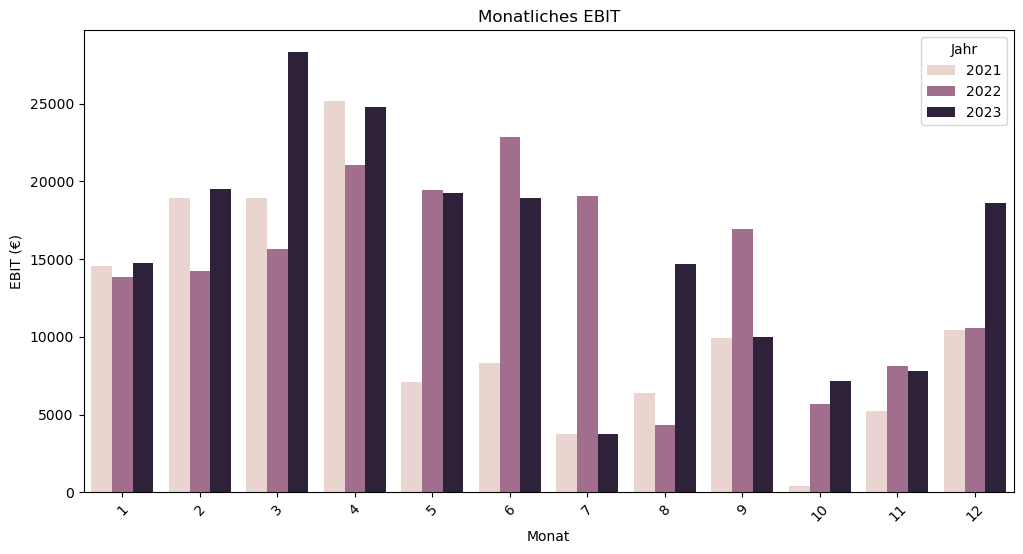

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df.index.month, y=df["EBIT"], hue=df.index.year)
plt.title("Monatliches EBIT")
plt.ylabel("EBIT (€)")
plt.xticks(rotation=45)
plt.legend(title="Jahr")

plt.show()

---

### ⏳ **4. Cash Conversion Cycle (CCC)**
**Visualisierung:**  
- **Balkendiagramm oder Liniendiagramm** zur Darstellung des CCC über die Monate
- **Stacked Bar Chart**, um Lagerdauer, Forderungslaufzeit und Verbindlichkeitenlaufzeit nebeneinander zu zeigen

📌 **Warum?**  
- Der CCC gibt an, wie effizient ein Unternehmen Kapital in Cash umwandelt.
- Ein gestapeltes Diagramm zeigt, welcher Faktor den CCC am meisten beeinflusst.

**📌 Umsetzung**

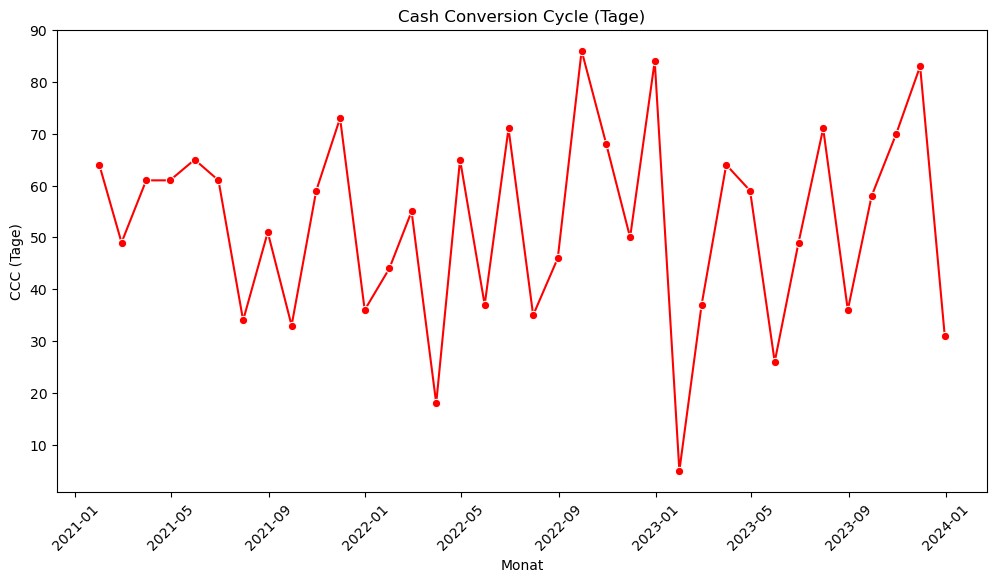

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y=df["Cash_Conversion_Cycle_Tage"], marker="o", color="r")
plt.title("Cash Conversion Cycle (Tage)")
plt.ylabel("CCC (Tage)")
plt.xticks(rotation=45)
plt.show()

Für eine **gestapelte Balkengrafik**, um die Bestandteile des CCC zu vergleichen:

<Figure size 1200x600 with 0 Axes>

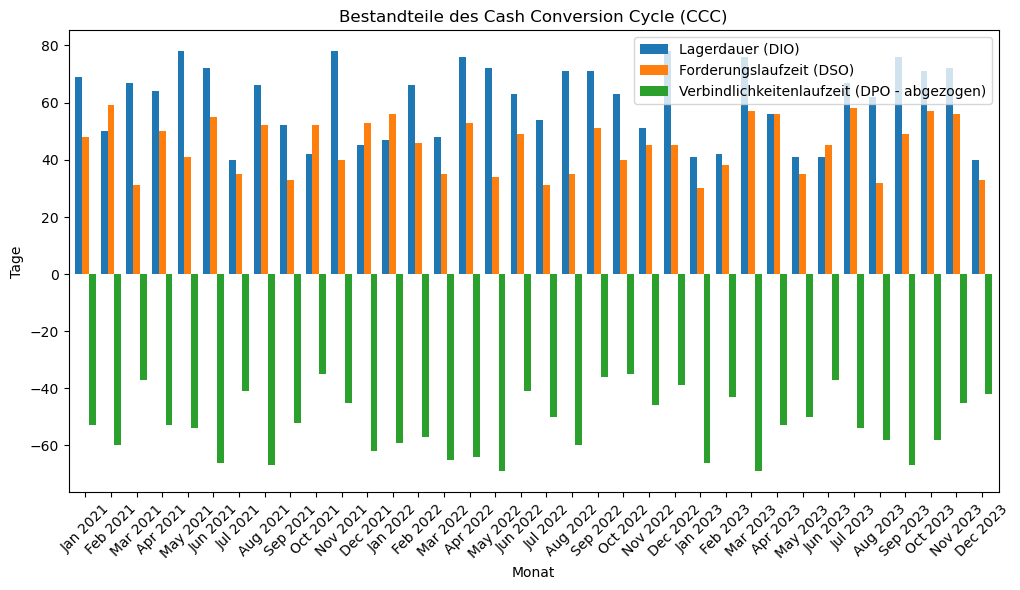

In [19]:

df_ccc = df[["Lagerdauer_Tage", "Forderungslaufzeit_Tage", "Verbindlichkeitenlaufzeit_Tage"]].copy()

# DPO-Werte negativ darstellen, um den Abzug zu visualisieren
df_ccc["Verbindlichkeitenlaufzeit_Tage"] *= -1

# Balkendiagramm erstellen
plt.figure(figsize=(12, 6))
df_ccc.plot(kind="bar", figsize=(12, 6), width=0.8)

# Titel und Achsenbeschriftungen setzen
plt.title("Bestandteile des Cash Conversion Cycle (CCC)")
plt.ylabel("Tage")
plt.xlabel("Monat")

# X-Ticks mit Monatsnamen formatieren
plt.xticks(ticks=range(len(df.index)), labels=df.index.strftime("%b %Y"), rotation=45)

# Legende aktualisieren
plt.legend(["Lagerdauer (DIO)", "Forderungslaufzeit (DSO)", "Verbindlichkeitenlaufzeit (DPO - abgezogen)"])

# Diagramm anzeigen
plt.show()
